# Superstore Sales Analysis

This notebook analyzes the Global Superstore dataset using SQL queries via SQLite and Python.  
The goal is to explore sales patterns, identify top performers, and uncover business insights across regions, categories, and customers.

**Dataset:** 9,994 orders | 21 columns | 2020 – 2023  
**Tools:** Python, SQLite, Pandas, Matplotlib, Seaborn

## 1. Setup

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

conn = sqlite3.connect('superstore.db')

def run(query):
    return pd.read_sql_query(query, conn)

print('Connected to database.')

Connected to database.


## 2. Table Exploration

In [3]:
df = run('SELECT * FROM orders LIMIT 5')
print(f'Columns: {list(df.columns)}')
df

Columns: ['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2023-100000,2023-08-02,2023-08-04,Standard Class,CUST-005,Hunter Lopez,Home Office,United States,Colorado,...,65302,West,FURN-004,Furniture,Tables,Ikea Desk,4144.97,11,0.5,-405.53
1,2,CA-2020-100001,2020-03-06,2020-03-08,Second Class,CUST-018,Brian Moss,Corporate,United States,Washington,...,30926,West,TECH-004,Technology,Phones,Logitech Mouse,3869.84,8,0.0,1181.40
2,3,CA-2023-100002,2023-11-30,2023-12-05,Same Day,CUST-004,Tom Ashbrook,Consumer,United States,Michigan,...,15695,Central,TECH-006,Technology,Accessories,Xerox Copier,490.26,2,0.2,104.05
3,4,CA-2022-100003,2022-07-29,2022-08-04,Standard Class,CUST-019,Sanjit Engle,Consumer,United States,Nevada,...,40512,West,TECH-006,Technology,Machines,Xerox Copier,431.34,1,0.2,190.28
4,5,CA-2020-100004,2020-07-25,2020-07-30,Second Class,CUST-012,Yoseph Carroll,Corporate,United States,Missouri,...,32431,Central,OFFI-003,Office Supplies,Storage,3M Tape,627.66,11,0.0,135.25


In [4]:
run('''
    SELECT
        COUNT(*)                    AS total_rows,
        COUNT(DISTINCT Customer_ID) AS unique_customers,
        COUNT(DISTINCT Order_ID)    AS unique_orders,
        COUNT(DISTINCT Product_ID)  AS unique_products,
        COUNT(DISTINCT Region)      AS regions,
        COUNT(DISTINCT Category)    AS categories,
        COUNT(DISTINCT State)       AS states
    FROM orders
''')

,total_rows,unique_customers,unique_orders,unique_products,regions,categories,states
0,9994,20,9994,24,4,3,24


In [5]:
run('''
    SELECT
        MIN(Order_Date) AS first_order,
        MAX(Order_Date) AS last_order
    FROM orders
''')

,first_order,last_order
0,2020-01-01,2023-12-31


## 3. Filtering with WHERE

In [6]:
run('''
    SELECT Region,
           COUNT(*)             AS orders,
           ROUND(SUM(Sales), 2) AS total_sales
    FROM orders
    WHERE Region = 'West'
    GROUP BY Region
''')

,Region,orders,total_sales
0,West,2559,5375720.23


In [7]:
run('''
    SELECT Category,
           COUNT(*)             AS orders,
           ROUND(SUM(Sales), 2) AS total_sales,
           ROUND(AVG(Sales), 2) AS avg_sale
    FROM orders
    WHERE Category = 'Technology'
    GROUP BY Category
''')

,Category,orders,total_sales,avg_sale
0,Technology,3360,8428017.49,2508.34


In [8]:
run('''
    SELECT strftime('%Y', Order_Date) AS year,
           COUNT(*)                   AS orders,
           ROUND(SUM(Sales), 2)       AS total_sales
    FROM orders
    WHERE strftime('%Y', Order_Date) = '2023'
    GROUP BY year
''')

,year,orders,total_sales
0,2023,2546,5233577.63


In [9]:
run('''
    SELECT Customer_Name,
           Product_Name,
           Sales,
           Profit,
           Region
    FROM orders
    WHERE Sales > 1000
    ORDER BY Sales DESC
    LIMIT 10
''')

,Customer_Name,Product_Name,Sales,Profit,Region
0,Ken Lonsdale,Humanscale Ergonomic Chair,13913.48,1774.83,Central
1,Janet Molinari,Lorell File Cabinet,13854.96,-1008.67,Central
2,Christopher Conant,Bevis Round Table,13629.42,5266.02,South
3,Bill Eplett,Sauder Bookcase,13587.98,3950.19,South
4,Chloris Kastensmidt,Humanscale Ergonomic Chair,13303.50,-966.34,East
5,Yoseph Carroll,Bevis Round Table,12990.64,2120.88,South
6,Bill Eplett,Ikea Desk,12982.20,1742.33,South
7,Greg Tran,Bretford Conference Table,12834.22,4186.35,Central
8,Chloris Kastensmidt,Lorell File Cabinet,12634.44,4116.04,South
9,Yoseph Carroll,Humanscale Ergonomic Chair,12534.34,5608.49,South


In [10]:
run('''
    SELECT COUNT(*)              AS orders,
           ROUND(SUM(Profit), 2) AS total_profit
    FROM orders
    WHERE Discount = 0 AND Profit > 0
''')

,orders,total_profit
0,2418,1369835.4


## 4. Aggregations with GROUP BY

In [11]:
region_df = run('''
    SELECT Region,
           COUNT(*)                  AS orders,
           ROUND(SUM(Sales), 2)      AS total_sales,
           ROUND(SUM(Profit), 2)     AS total_profit,
           ROUND(AVG(Sales), 2)      AS avg_order_value,
           SUM(Quantity)             AS units_sold
    FROM orders
    GROUP BY Region
    ORDER BY total_sales DESC
''')
region_df

,Region,orders,total_sales,total_profit,avg_order_value,units_sold
0,West,2559,5375720.23,767694.01,2100.71,19010
1,East,2469,5250974.35,755516.34,2126.76,18405
2,South,2515,5167341.62,751751.16,2054.61,18655
3,Central,2451,4973804.66,743618.39,2029.30,18220


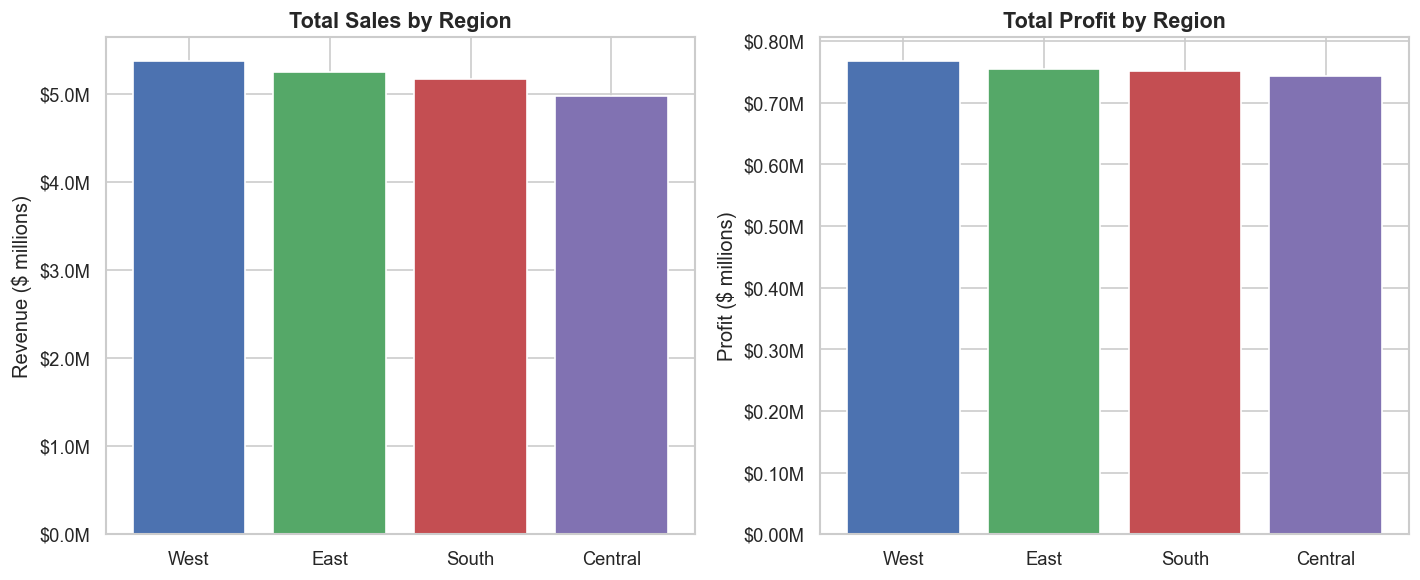

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

axes[0].bar(region_df['Region'], region_df['total_sales'] / 1e6, color=colors, edgecolor='white')
axes[0].set_title('Total Sales by Region', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue ($ millions)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

axes[1].bar(region_df['Region'], region_df['total_profit'] / 1e6, color=colors, edgecolor='white')
axes[1].set_title('Total Profit by Region', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit ($ millions)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.2f}M'))

plt.tight_layout()
plt.show()

In [13]:
cat_df = run('''
    SELECT Category,
           COUNT(*)                                  AS orders,
           ROUND(SUM(Sales), 2)                      AS total_sales,
           ROUND(SUM(Profit), 2)                     AS total_profit,
           ROUND(AVG(Discount) * 100, 1)             AS avg_discount_pct,
           ROUND(SUM(Profit) / SUM(Sales) * 100, 2)  AS margin_pct
    FROM orders
    GROUP BY Category
    ORDER BY total_sales DESC
''')
cat_df

,Category,orders,total_sales,total_profit,avg_discount_pct,margin_pct
0,Furniture,3319,10293720.56,1541092.37,19.2,14.97
1,Technology,3360,8428017.49,1187455.31,19.3,14.09
2,Office Supplies,3315,2046102.81,290032.22,18.6,14.17


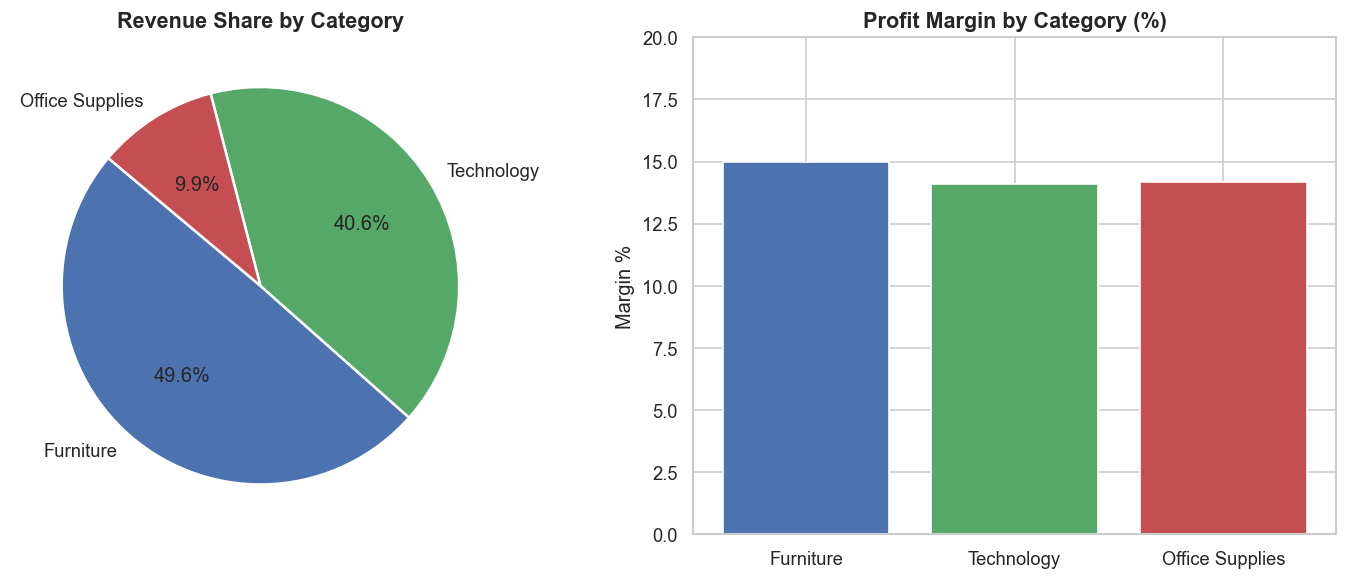

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cat_colors = ['#4C72B0', '#55A868', '#C44E52']

axes[0].pie(
    cat_df['total_sales'],
    labels=cat_df['Category'],
    autopct='%1.1f%%',
    colors=cat_colors,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[0].set_title('Revenue Share by Category', fontsize=13, fontweight='bold')

axes[1].bar(cat_df['Category'], cat_df['margin_pct'], color=cat_colors, edgecolor='white')
axes[1].set_title('Profit Margin by Category (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Margin %')
axes[1].set_ylim(0, 20)

plt.tight_layout()
plt.show()

In [15]:
run('''
    SELECT Segment,
           COUNT(*)                      AS orders,
           ROUND(SUM(Sales), 2)          AS total_sales,
           ROUND(SUM(Profit), 2)         AS total_profit,
           COUNT(DISTINCT Customer_ID)   AS unique_customers
    FROM orders
    GROUP BY Segment
    ORDER BY total_sales DESC
''')

,Segment,orders,total_sales,total_profit,unique_customers
0,Corporate,3379,7111269.96,998368.72,20
1,Home Office,3320,6921799.71,1022827.65,20
2,Consumer,3295,6734771.19,997383.53,20


In [16]:
run('''
    SELECT Ship_Mode,
           COUNT(*)                AS orders,
           ROUND(AVG(Sales), 2)    AS avg_sale,
           ROUND(AVG(Quantity), 2) AS avg_quantity,
           ROUND(SUM(Sales), 2)    AS total_sales
    FROM orders
    GROUP BY Ship_Mode
    ORDER BY total_sales DESC
''')

,Ship_Mode,orders,avg_sale,avg_quantity,total_sales
0,Same Day,2555,2106.69,7.40,5382589.03
1,Second Class,2500,2079.50,7.46,5198760.06
2,First Class,2452,2085.27,7.43,5113087.59
3,Standard Class,2487,2039.97,7.45,5073404.18


## 5. Top Performers

In [17]:
top_products = run('''
    SELECT Product_Name,
           Category,
           COUNT(*)               AS times_ordered,
           SUM(Quantity)          AS units_sold,
           ROUND(SUM(Sales), 2)   AS revenue,
           ROUND(SUM(Profit), 2)  AS profit
    FROM orders
    GROUP BY Product_Name, Category
    ORDER BY revenue DESC
    LIMIT 10
''')
top_products

,Product_Name,Category,times_ordered,units_sold,revenue,profit
0,Bevis Round Table,Furniture,435,3242,1464073.59,232557.68
1,Lorell File Cabinet,Furniture,430,3143,1340272.98,220336.53
2,Hon Executive Chair,Furniture,429,2999,1297511.18,168154.58
3,Humanscale Ergonomic Chair,Furniture,398,2890,1283600.63,190476.61
4,Ikea Desk,Furniture,413,2968,1274371.79,179072.92
5,Bretford Conference Table,Furniture,421,3101,1271337.34,165008.35
6,Sauder Bookcase,Furniture,396,3025,1235548.39,219646.72
7,Cisco Smart Switch,Technology,447,3410,1135182.39,164362.46
8,Bush Wardrobe,Furniture,397,2893,1127004.66,165838.98
9,Logitech Mouse,Technology,441,3313,1107221.51,169804.54


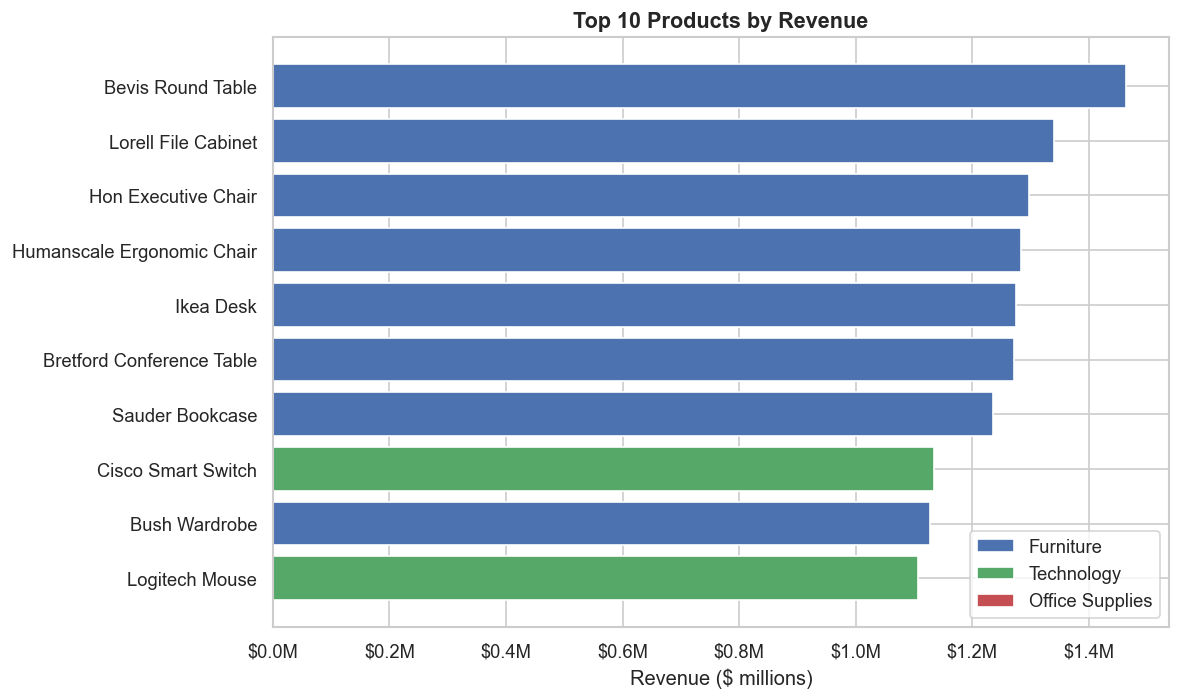

In [18]:
plt.figure(figsize=(10, 6))
colors_map = {'Furniture': '#4C72B0', 'Technology': '#55A868', 'Office Supplies': '#C44E52'}
bar_colors = [colors_map[c] for c in top_products['Category']]

plt.barh(top_products['Product_Name'][::-1], top_products['revenue'][::-1] / 1e6, color=bar_colors[::-1], edgecolor='white')
plt.xlabel('Revenue ($ millions)')
plt.title('Top 10 Products by Revenue', fontsize=13, fontweight='bold')
plt.xaxis = plt.gca().xaxis
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors_map.items()]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

In [19]:
run('''
    SELECT Sub_Category,
           Category,
           COUNT(*)                                  AS orders,
           ROUND(SUM(Sales), 2)                      AS total_sales,
           ROUND(SUM(Profit), 2)                     AS total_profit,
           ROUND(SUM(Profit) / SUM(Sales) * 100, 1)  AS margin_pct
    FROM orders
    GROUP BY Sub_Category, Category
    ORDER BY total_sales DESC
    LIMIT 10
''')

,Sub_Category,Category,orders,total_sales,total_profit,margin_pct
0,Furnishings,Furniture,852,2648577.17,427733.47,16.1
1,Chairs,Furniture,823,2581344.02,368244.48,14.3
2,Bookcases,Furniture,816,2542650.50,353770.52,13.9
3,Tables,Furniture,828,2521148.87,391343.90,15.5
4,Copiers,Technology,854,2173866.78,297469.58,13.7
5,Machines,Technology,813,2102426.12,313597.27,14.9
6,Accessories,Technology,839,2080301.66,280164.32,13.5
7,Phones,Technology,854,2071422.93,296224.14,14.3
8,Fasteners,Office Supplies,594,359518.82,52876.62,14.7
9,Labels,Office Supplies,551,350391.92,47146.56,13.5


In [20]:
top_customers = run('''
    SELECT Customer_Name,
           Segment,
           Region,
           COUNT(DISTINCT Order_ID)  AS orders,
           ROUND(SUM(Sales), 2)      AS lifetime_value,
           ROUND(SUM(Profit), 2)     AS total_profit,
           ROUND(AVG(Sales), 2)      AS avg_order_value
    FROM orders
    GROUP BY Customer_Name, Segment, Region
    ORDER BY lifetime_value DESC
    LIMIT 10
''')
top_customers

,Customer_Name,Segment,Region,orders,lifetime_value,total_profit,avg_order_value
0,Bill Eplett,Home Office,South,58,145016.41,22861.04,2500.28
1,Steven Roelle,Home Office,East,48,144526.54,22542.15,3010.97
2,Mike Gockenbach,Consumer,South,58,142644.53,19941.21,2459.39
3,Adrian Barton,Home Office,South,42,132025.28,24198.91,3143.46
4,Chloris Kastensmidt,Consumer,East,40,131526.67,19734.94,3288.17
5,Raymond Buch,Home Office,West,48,130533.76,18940.56,2719.45
6,Raymond Buch,Corporate,West,45,122729.73,21652.07,2727.33
7,Bill Eplett,Home Office,West,53,120577.46,15351.39,2275.05
8,Janet Molinari,Consumer,West,48,120556.83,20075.08,2511.60
9,Chloris Kastensmidt,Corporate,West,45,120224.50,19546.55,2671.66


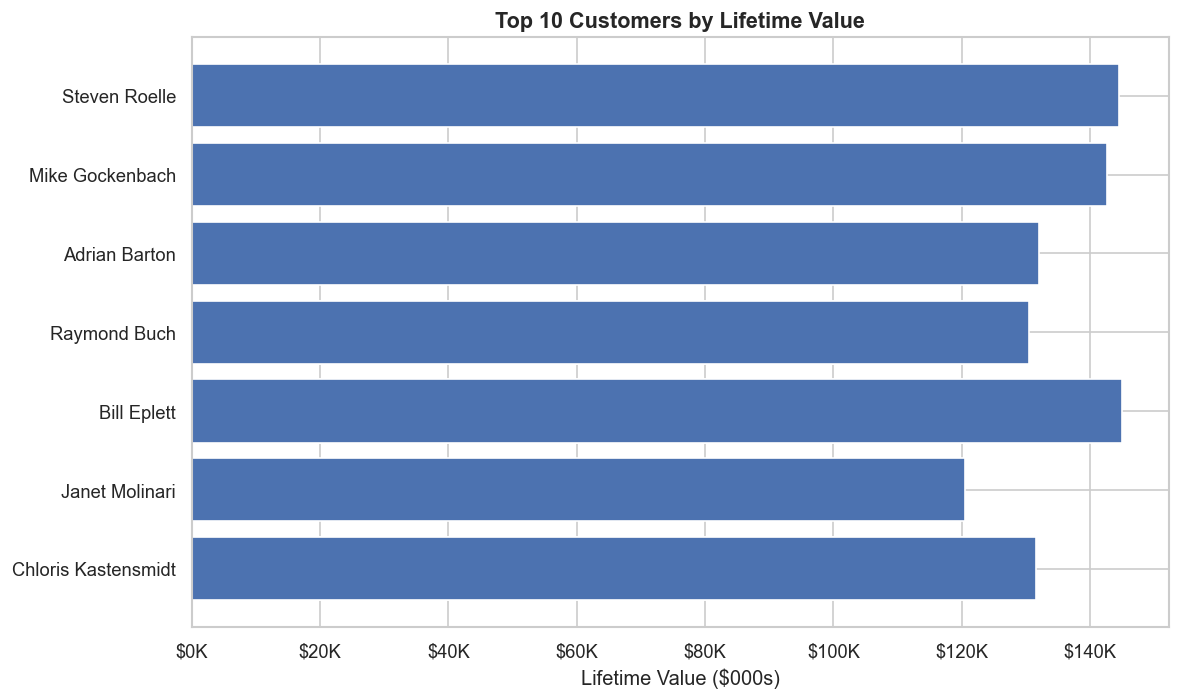

In [21]:
plt.figure(figsize=(10, 6))
plt.barh(top_customers['Customer_Name'][::-1], top_customers['lifetime_value'][::-1] / 1e3,
         color='#4C72B0', edgecolor='white')
plt.xlabel('Lifetime Value ($000s)')
plt.title('Top 10 Customers by Lifetime Value', fontsize=13, fontweight='bold')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
plt.tight_layout()
plt.show()

In [22]:
run('''
    SELECT State,
           Region,
           COUNT(*)               AS orders,
           ROUND(SUM(Sales), 2)   AS total_sales,
           ROUND(SUM(Profit), 2)  AS total_profit
    FROM orders
    GROUP BY State, Region
    ORDER BY total_sales DESC
    LIMIT 10
''')

,State,Region,orders,total_sales,total_profit
0,Nevada,West,455,987228.99,138855.61
1,Pennsylvania,East,429,966639.84,140645.15
2,Tennessee,South,437,942078.64,157229.44
3,Georgia,South,458,935551.54,137329.16
4,North Carolina,East,406,921823.98,144109.51
5,Florida,East,429,918368.18,130965.27
6,Washington,West,409,917529.56,135252.41
7,Colorado,West,460,895287.36,120254.75
8,California,West,412,892329.71,119514.73
9,New York,East,417,880127.41,130432.37


## 6. Business Use Cases

In [23]:
monthly_df = run('''
    SELECT strftime('%Y-%m', Order_Date) AS month,
           COUNT(*)                      AS orders,
           ROUND(SUM(Sales), 2)          AS monthly_sales,
           ROUND(SUM(Profit), 2)         AS monthly_profit,
           ROUND(AVG(Sales), 2)          AS avg_order_value
    FROM orders
    GROUP BY month
    ORDER BY month
''')
monthly_df.head()

,month,orders,monthly_sales,monthly_profit,avg_order_value
0,2020-01,230,512353.93,72122.76,2227.63
1,2020-02,186,420131.57,70389.68,2258.77
2,2020-03,189,450032.52,67793.85,2381.12
3,2020-04,193,349409.53,57904.18,1810.41
4,2020-05,215,527042.35,73047.45,2451.36


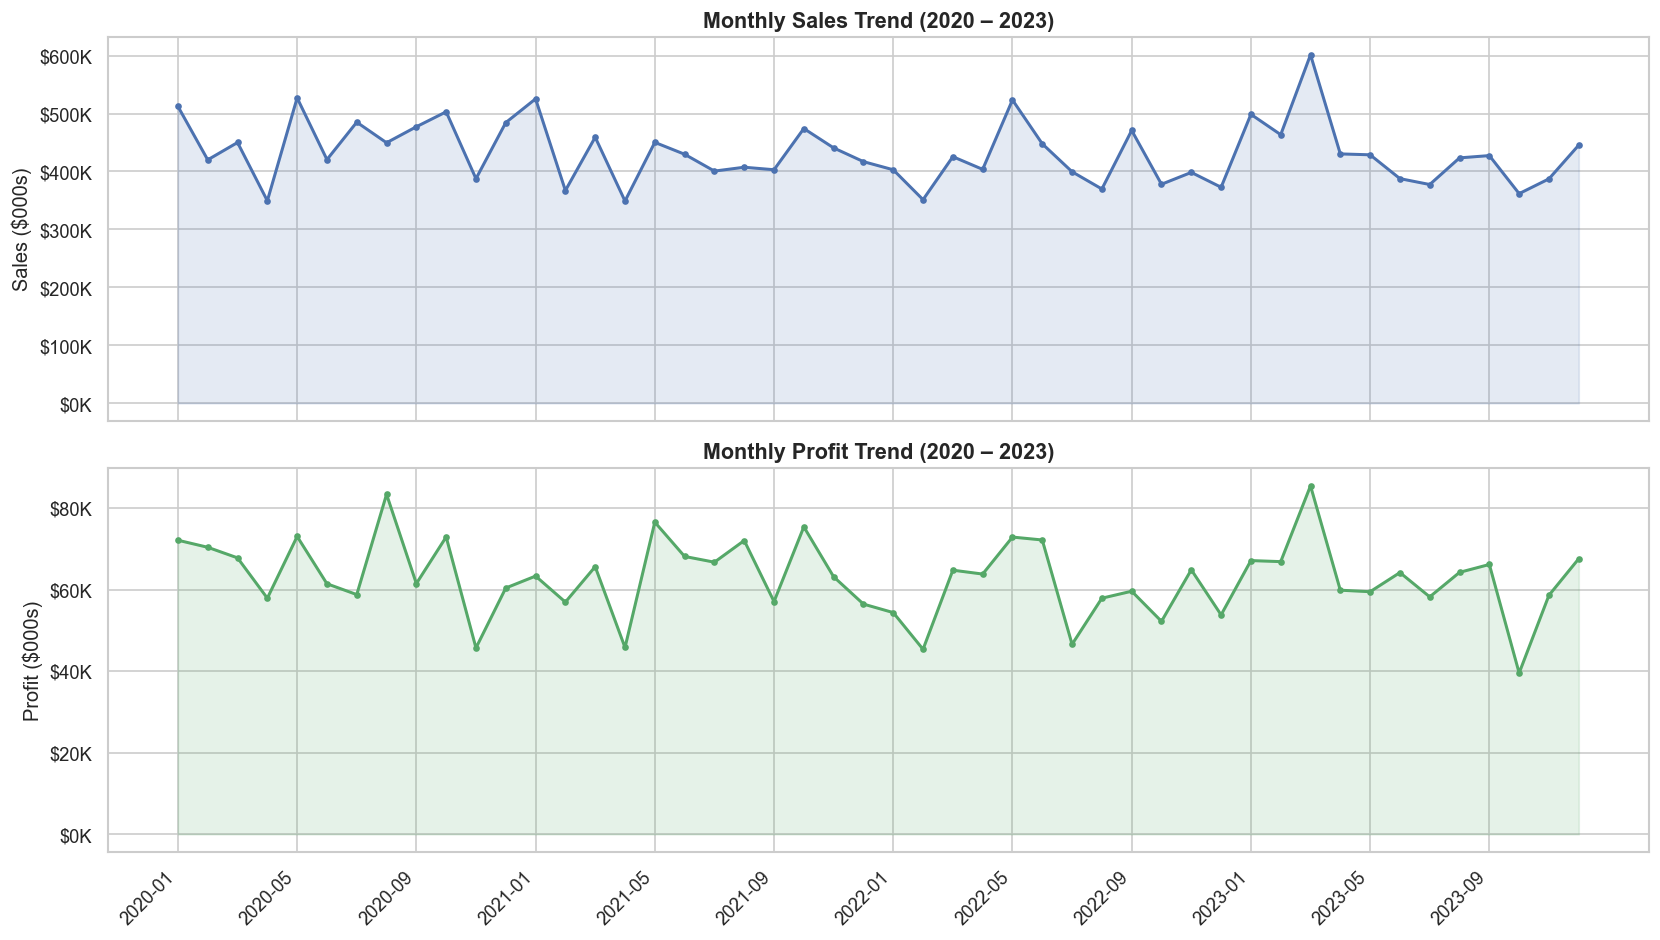

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(monthly_df['month'], monthly_df['monthly_sales'] / 1e3,
             color='#4C72B0', linewidth=1.8, marker='o', markersize=3)
axes[0].set_title('Monthly Sales Trend (2020 – 2023)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales ($000s)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
axes[0].fill_between(monthly_df['month'], monthly_df['monthly_sales'] / 1e3, alpha=0.15, color='#4C72B0')

axes[1].plot(monthly_df['month'], monthly_df['monthly_profit'] / 1e3,
             color='#55A868', linewidth=1.8, marker='o', markersize=3)
axes[1].set_title('Monthly Profit Trend (2020 – 2023)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit ($000s)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
axes[1].fill_between(monthly_df['month'], monthly_df['monthly_profit'] / 1e3, alpha=0.15, color='#55A868')

tick_positions = list(range(0, len(monthly_df), 4))
tick_labels = [monthly_df['month'].iloc[i] for i in tick_positions]
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [25]:
yearly_df = run('''
    SELECT strftime('%Y', Order_Date)  AS year,
           COUNT(*)                    AS orders,
           ROUND(SUM(Sales), 2)        AS annual_sales,
           ROUND(SUM(Profit), 2)       AS annual_profit,
           COUNT(DISTINCT Customer_ID) AS customers
    FROM orders
    GROUP BY year
    ORDER BY year
''')
yearly_df

,year,orders,annual_sales,annual_profit,customers
0,2020,2521,5466386.40,785409.48,20
1,2021,2500,5123654.14,767296.57,20
2,2022,2427,4944222.69,708444.46,20
3,2023,2546,5233577.63,757429.39,20


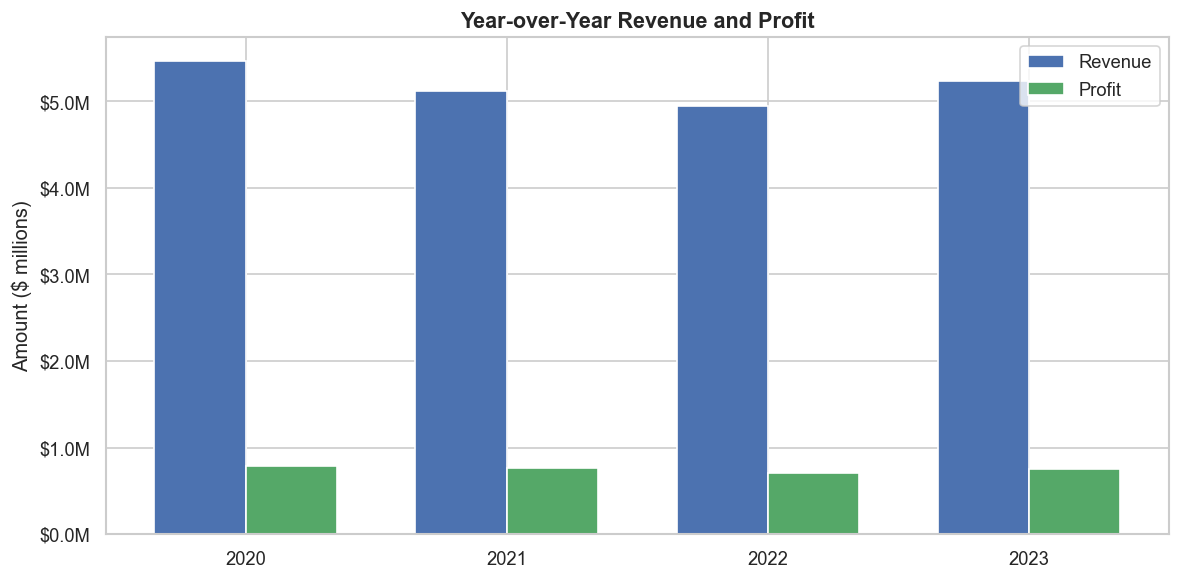

In [26]:
x = range(len(yearly_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], yearly_df['annual_sales'] / 1e6,
       width=width, label='Revenue', color='#4C72B0', edgecolor='white')
ax.bar([i + width/2 for i in x], yearly_df['annual_profit'] / 1e6,
       width=width, label='Profit', color='#55A868', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(yearly_df['year'])
ax.set_ylabel('Amount ($ millions)')
ax.set_title('Year-over-Year Revenue and Profit', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.1f}M'))
ax.legend()

plt.tight_layout()
plt.show()

In [27]:
discount_df = run('''
    SELECT
        CASE
            WHEN Discount = 0     THEN 'No discount'
            WHEN Discount <= 0.20 THEN 'Low (1-20%)'
            WHEN Discount <= 0.40 THEN 'Medium (21-40%)'
            ELSE                       'High (>40%)'
        END                       AS discount_tier,
        COUNT(*)                  AS orders,
        ROUND(AVG(Profit), 2)     AS avg_profit,
        ROUND(SUM(Sales), 2)      AS total_sales
    FROM orders
    GROUP BY discount_tier
    ORDER BY avg_profit DESC
''')
discount_df

,discount_tier,orders,avg_profit,total_sales
0,No discount,3295,361.69,8505527.47
1,Low (1-20%),3322,310.15,7022622.12
2,Medium (21-40%),2278,251.90,3789634.69
3,High (>40%),1099,202.61,1450056.58


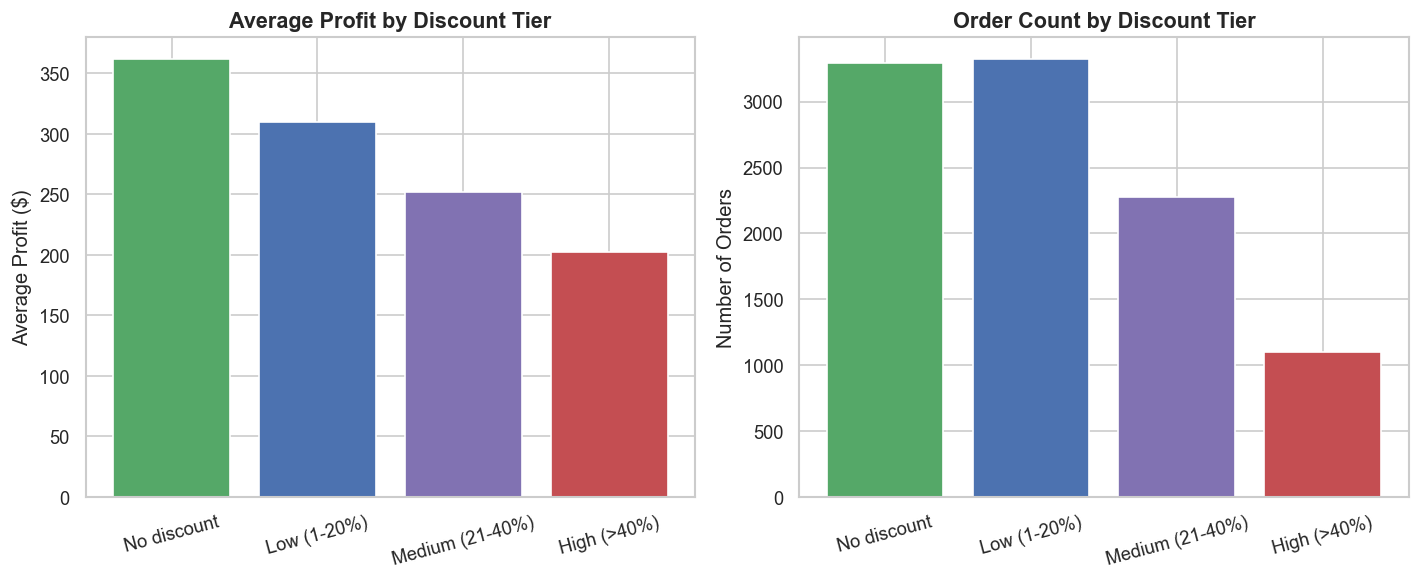

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

tier_order = ['No discount', 'Low (1-20%)', 'Medium (21-40%)', 'High (>40%)']
discount_df['discount_tier'] = pd.Categorical(discount_df['discount_tier'], categories=tier_order, ordered=True)
discount_df = discount_df.sort_values('discount_tier')

tier_colors = ['#55A868', '#4C72B0', '#8172B2', '#C44E52']

axes[0].bar(discount_df['discount_tier'], discount_df['avg_profit'],
            color=tier_colors, edgecolor='white')
axes[0].set_title('Average Profit by Discount Tier', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Profit ($)')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(discount_df['discount_tier'], discount_df['orders'],
            color=tier_colors, edgecolor='white')
axes[1].set_title('Order Count by Discount Tier', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 7. Data Quality Checks

In [29]:
run('''
    SELECT
        SUM(CASE WHEN Customer_ID IS NULL THEN 1 ELSE 0 END) AS null_customer_id,
        SUM(CASE WHEN Sales       IS NULL THEN 1 ELSE 0 END) AS null_sales,
        SUM(CASE WHEN Order_Date  IS NULL THEN 1 ELSE 0 END) AS null_order_date,
        SUM(CASE WHEN Region      IS NULL THEN 1 ELSE 0 END) AS null_region,
        SUM(CASE WHEN Category    IS NULL THEN 1 ELSE 0 END) AS null_category
    FROM orders
''')

,null_customer_id,null_sales,null_order_date,null_region,null_category
0,0,0,0,0,0


In [30]:
dupes = run('''
    SELECT Order_ID, Customer_ID, Product_ID, COUNT(*) AS occurrences
    FROM orders
    GROUP BY Order_ID, Customer_ID, Product_ID
    HAVING COUNT(*) > 1
    ORDER BY occurrences DESC
    LIMIT 5
''')
print(f'Duplicate rows found: {len(dupes)}')
dupes

Duplicate rows found: 0


,Order_ID,Customer_ID,Product_ID,occurrences


In [31]:
run('''
    SELECT COUNT(*)                                                    AS loss_making_orders,
           ROUND(SUM(Profit), 2)                                       AS total_loss,
           ROUND(AVG(Discount) * 100, 1)                               AS avg_discount_pct,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders), 1)  AS pct_of_all_orders
    FROM orders
    WHERE Profit < 0
''')

,loss_making_orders,total_loss,avg_discount_pct,pct_of_all_orders
0,2610,-416647.26,18.9,26.1


In [32]:
run('''
    SELECT
        ROUND(MIN(Sales),  2) AS min_sale,
        ROUND(MAX(Sales),  2) AS max_sale,
        ROUND(AVG(Sales),  2) AS avg_sale,
        ROUND(MIN(Profit), 2) AS min_profit,
        ROUND(MAX(Profit), 2) AS max_profit,
        ROUND(AVG(Profit), 2) AS avg_profit
    FROM orders
''')

,min_sale,max_sale,avg_sale,min_profit,max_profit,avg_profit
0,4.73,13913.48,2078.03,-1537.11,5608.49,302.04


## 8. Key Takeaways

**Revenue is evenly spread across regions.** West leads at $5.4M, but all four regions fall within an 8% range — no single region is carrying the business.

**Furniture drives nearly half of revenue (49%)**, but its margin (14.97%) is only marginally higher than Technology (14.09%) and Office Supplies (14.17%). The category split suggests a healthy mix, though Office Supplies contributes only 10% of revenue despite a similar order count.

**Discounting hurts profitability significantly.** Average profit drops from $362 on undiscounted orders to $203 on heavily discounted ones — a 44% decline. With 26.1% of all orders already loss-making, aggressive discounting is the most direct lever to address.

**The customer base is small but high-value.** 20 unique customers generating nearly 10,000 orders indicates a repeat-heavy, B2B-style model. The top 10 customers each have lifetime values above $1M.

**No data quality issues were found.** Zero nulls across all key columns, no duplicate rows, and sales/profit values fall within expected ranges.

In [33]:
conn.close()